# Qwen Thesis Experiment Notebook

This notebook fine-tunes and evaluates a **decoder-only Qwen instruction model** for Mauritian Creole text restoration.

Your original JSON format can be:

```json
[
  {
    "id": 3,
    "text": "Les banla trace zot lavi boss... Zot ena 1 family pu soutenier",
    "standardized": "Les banla trasse zot lavi boss... Zot ena 1 family pu soutenir."
  }
]
```

The notebook converts this into an instruction-tuning format for Qwen:

```text
System: You restore Mauritian Creole text.
User: Restore the text: ...
Assistant: standardized sentence
```

It keeps the same comparison metrics and graph outputs as the ByT5, T5, and BiLSTM notebooks:

- CER
- WER
- chrF
- Exact Match
- Word Accuracy
- Punctuation Precision / Recall / F1
- Capitalization Accuracy / F1
- Training time
- Inference time
- GPU memory

It also adds Qwen-specific analysis:

- Prompt token length
- Response token length
- Prompt/response token ratio
- Label-mask ratio
- Chat template examples
- Generated response length
- Instruction-following checks
- Extra-text / explanation detection
- Output cleanup analysis
- LoRA trainable-parameter analysis

## 1. Install libraries

Run this once on RunPod if needed. This notebook uses Qwen with Transformers and PEFT/LoRA.

In [1]:
# Uncomment this cell on RunPod if needed.
# %pip install -U transformers datasets accelerate peft bitsandbytes sentencepiece sacrebleu jiwer scikit-learn pandas numpy matplotlib tqdm

## 2. Imports

In [1]:
import os
import re
import json
import time
import random
import platform
import warnings
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Any, Optional
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    TrainerCallback,
    BitsAndBytesConfig,
)

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

from jiwer import wer, cer
from sacrebleu.metrics import CHRF
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from IPython.display import display

warnings.filterwarnings("ignore")

## 3. Configuration

Edit the dataset path and column names here. The notebook accepts JSON, JSONL, or CSV.

In [2]:
EXPERIMENT_NAME = "qwen_mauritian_creole_text_restoration"

# Recommended first model for RTX 4090. You can change to Qwen/Qwen2.5-1.5B-Instruct if you want larger.
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# If you already have split files, set USE_EXISTING_SPLITS=True and edit split paths below.
USE_EXISTING_SPLITS = True
TRAIN_PATH = "/workspace/mauritian_creole_nlp/data/dataset_split/train.json"
VAL_PATH   = "/workspace/mauritian_creole_nlp/data/dataset_split/val.json"
TEST_PATH  = "/workspace/mauritian_creole_nlp/data/dataset_split/test.json"

# Original JSON fields
ID_COL = "id"
INPUT_COL = "text"
TARGET_COL = "standardized"

# Split settings if starting from one JSON file
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

OUTPUT_DIR = Path("results") / "qwen"
for sub in ["plots", "predictions", "analysis", "checkpoints", "converted_data"]:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

SEED = 18
MAX_SEQ_LENGTH = 512
MAX_NEW_TOKENS = 128

# Training settings
NUM_EPOCHS = 3
LEARNING_RATE = 2e-4
TRAIN_BATCH_SIZE = 2
EVAL_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.05

# LoRA settings
USE_4BIT = True
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# Evaluation settings
EVAL_SAMPLE_LIMIT = None             # Final train/val/test evaluation. Use None for full.
CURVE_EVAL_SAMPLE_LIMIT = 100        # Per-epoch validation generation for curves. Keep small to save time.

SYSTEM_PROMPT = (
    "You are a text normalization system for Mauritian Creole. "
    "Correct only spelling, orthographic variants, punctuation, and capitalization. "
    "Do not rewrite, paraphrase, translate, or change the meaning. "
    "Return only the corrected sentence."
)

USER_TEMPLATE = (
    "Normalize the following text while preserving the original wording and meaning. "
    "Correct only spelling, orthographic variants, punctuation, and capitalization.\n\n"
    "Text: {input_text}"
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 4. Environment and GPU information

In [3]:
def get_environment_info() -> Dict[str, Any]:
    info = {
        "experiment_name": EXPERIMENT_NAME,
        "timestamp": datetime.now().isoformat(),
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "pytorch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "model_name": MODEL_NAME,
        "seed": SEED,
        "device": str(DEVICE),
        "use_4bit": USE_4BIT,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
    }
    if torch.cuda.is_available():
        info.update({
            "gpu_name": torch.cuda.get_device_name(0),
            "gpu_count": torch.cuda.device_count(),
            "gpu_capability": str(torch.cuda.get_device_capability(0)),
        })
    return info

env_info = get_environment_info()
print(json.dumps(env_info, indent=2))
with open(OUTPUT_DIR / "environment_info.json", "w", encoding="utf-8") as f:
    json.dump(env_info, f, indent=2, ensure_ascii=False)

{
  "experiment_name": "qwen_mauritian_creole_text_restoration",
  "timestamp": "2026-08-05T09:03:24.755563",
  "python_version": "3.12.3",
  "platform": "Linux-6.8.0-94-generic-x86_64-with-glibc2.39",
  "pytorch_version": "2.8.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "model_name": "Qwen/Qwen2.5-1.5B-Instruct",
  "seed": 18,
  "device": "cuda",
  "use_4bit": true,
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05,
  "gpu_name": "NVIDIA GeForce RTX 4090",
  "gpu_count": 1,
  "gpu_capability": "(8, 9)"
}


## 5. Load JSON / JSONL / CSV dataset

In [4]:
def load_any_dataset(path: str) -> pd.DataFrame:
    path_obj = Path(path)
    if not path_obj.exists():
        raise FileNotFoundError(f"Dataset not found: {path}")

    if path_obj.suffix.lower() == ".json":
        with open(path_obj, "r", encoding="utf-8") as f:
            data = json.load(f)
        if isinstance(data, dict):
            # Supports either a top-level list or a dict containing a list.
            possible_lists = [v for v in data.values() if isinstance(v, list)]
            if not possible_lists:
                raise ValueError("JSON dict does not contain a list of examples.")
            data = possible_lists[0]
        df = pd.DataFrame(data)
    elif path_obj.suffix.lower() == ".jsonl":
        rows = []
        with open(path_obj, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
        df = pd.DataFrame(rows)
    elif path_obj.suffix.lower() == ".csv":
        df = pd.read_csv(path_obj)
    else:
        raise ValueError("Unsupported file type. Use .json, .jsonl, or .csv")

    return df

def validate_dataset_columns(df: pd.DataFrame) -> pd.DataFrame:
    required = [INPUT_COL, TARGET_COL]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Found columns: {list(df.columns)}")
    if ID_COL not in df.columns:
        df[ID_COL] = range(1, len(df) + 1)
    df = df[[ID_COL, INPUT_COL, TARGET_COL]].copy()
    df[INPUT_COL] = df[INPUT_COL].fillna("").astype(str)
    df[TARGET_COL] = df[TARGET_COL].fillna("").astype(str)
    df = df[(df[INPUT_COL].str.strip() != "") & (df[TARGET_COL].str.strip() != "")].reset_index(drop=True)
    return df

## 6. Create train / validation / test splits

This cell converts your JSON into clean split files for Qwen.

In [5]:
def split_dataframe(df: pd.DataFrame, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(shuffled)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train = shuffled.iloc[:n_train].reset_index(drop=True)
    val = shuffled.iloc[n_train:n_train+n_val].reset_index(drop=True)
    test = shuffled.iloc[n_train+n_val:].reset_index(drop=True)
    return train, val, test

if USE_EXISTING_SPLITS:
    train_df = validate_dataset_columns(load_any_dataset(TRAIN_PATH))
    val_df = validate_dataset_columns(load_any_dataset(VAL_PATH))
    test_df = validate_dataset_columns(load_any_dataset(TEST_PATH))
else:
    full_df = validate_dataset_columns(load_any_dataset(DATA_PATH))
    train_df, val_df, test_df = split_dataframe(full_df, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, SEED)

# Always ensure the split column exists
train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    df.to_json(OUTPUT_DIR / "converted_data" / f"{name}.json", orient="records", force_ascii=False, indent=2)
    df.to_csv(OUTPUT_DIR / "converted_data" / f"{name}.csv", index=False, encoding="utf-8")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
display(train_df.head())

Train: (11064, 4)
Validation: (1383, 4)
Test: (1383, 4)


,id,text,standardized,split
0,3745,La dan zenfant ki victime femme bizin pran con...,Ladan zanfan ki victime femme bizin pran kont ...,train
1,13277,Or believe li couyoun li kit so parliamentary ...,Or believe li kuyon. Li kite so parliamentary ...,train
2,9150,Apres zot dire ena soldat dan moris. Mo sire v...,Apre zot dire ena soldat dan Moris. Mo sir vac...,train
3,7031,Et voilà c’est reparti avec bann intellectuel ...,Et voilà. Se reparti avec bann intellectuel fa...,train
4,5540,Wadir dan film,Wadire dan film.,train


## 7. Convert JSON examples to Qwen instruction format

In [6]:
def build_user_prompt(input_text: str) -> str:
    return USER_TEMPLATE.format(input_text=str(input_text))

def build_messages(input_text: str, target_text: Optional[str] = None) -> List[Dict[str, str]]:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_prompt(input_text)},
    ]
    if target_text is not None:
        messages.append({"role": "assistant", "content": str(target_text)})
    return messages

def convert_to_instruction_records(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in df.iterrows():
        input_text = row[INPUT_COL]
        target_text = row[TARGET_COL]
        rows.append({
            "id": row[ID_COL],
            "input_text": input_text,
            "target_text": target_text,
            "system_prompt": SYSTEM_PROMPT,
            "user_prompt": build_user_prompt(input_text),
            "messages": build_messages(input_text, target_text),
        })
    return pd.DataFrame(rows)

train_instr = convert_to_instruction_records(train_df)
val_instr = convert_to_instruction_records(val_df)
test_instr = convert_to_instruction_records(test_df)

for name, df in [("train", train_instr), ("validation", val_instr), ("test", test_instr)]:
    df.to_json(OUTPUT_DIR / "converted_data" / f"{name}_qwen_instruction.json", orient="records", force_ascii=False, indent=2)

print("Example converted record:")
print(json.dumps(train_instr.iloc[0].to_dict(), indent=2, ensure_ascii=False))

Example converted record:
{
  "id": 3745,
  "input_text": "La dan zenfant ki victime femme bizin pran contre pas laisse zote peige'",
  "target_text": "Ladan zanfan ki victime femme bizin pran kont pas laisse zot pyez'.",
  "system_prompt": "You are a text normalization system for Mauritian Creole. Correct only spelling, orthographic variants, punctuation, and capitalization. Do not rewrite, paraphrase, translate, or change the meaning. Return only the corrected sentence.",
  "user_prompt": "Normalize the following text while preserving the original wording and meaning. Correct only spelling, orthographic variants, punctuation, and capitalization.\n\nText: La dan zenfant ki victime femme bizin pran contre pas laisse zote peige'",
  "messages": [
    {
      "role": "system",
      "content": "You are a text normalization system for Mauritian Creole. Correct only spelling, orthographic variants, punctuation, and capitalization. Do not rewrite, paraphrase, translate, or change the meanin

## 8. Dataset statistics

In [7]:
def basic_text_stats(df: pd.DataFrame, text_col: str, split_name: str) -> Dict[str, Any]:
    texts = df[text_col].astype(str).tolist()
    words = [w for t in texts for w in t.split()]
    chars = [ch for t in texts for ch in t]
    return {
        "split": split_name,
        "column": text_col,
        "num_rows": len(df),
        "num_words": len(words),
        "word_vocab_size": len(set(words)),
        "num_characters": len(chars),
        "character_vocab_size": len(set(chars)),
        "avg_words_per_sentence": float(np.mean([len(t.split()) for t in texts])) if texts else 0,
        "avg_chars_per_sentence": float(np.mean([len(t) for t in texts])) if texts else 0,
        "max_chars_sentence": int(max([len(t) for t in texts], default=0)),
    }

stats_rows = []
for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    stats_rows.append(basic_text_stats(df, INPUT_COL, split_name))
    stats_rows.append(basic_text_stats(df, TARGET_COL, split_name))

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(OUTPUT_DIR / "dataset_statistics.csv", index=False, encoding="utf-8")
display(stats_df)

,split,column,num_rows,num_words,word_vocab_size,num_characters,character_vocab_size,avg_words_per_sentence,avg_chars_per_sentence,max_chars_sentence
0,train,text,11064,195282,25124,1000800,392,17.650217,90.455531,1261
1,train,standardized,11064,193408,21436,1012864,366,17.480839,91.545915,1246
2,validation,text,1383,24611,6764,126035,211,17.795372,91.131598,1073
3,validation,standardized,1383,24351,5982,127555,206,17.607375,92.230658,1053
4,test,text,1383,24784,6822,126139,257,17.920463,91.206797,1123
5,test,standardized,1383,24512,6143,127598,249,17.723789,92.261750,1183


## 9. Load Qwen tokenizer

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print("Tokenizer:", tokenizer.__class__.__name__)
print("Vocabulary size:", len(tokenizer))
print("Pad token:", tokenizer.pad_token, tokenizer.pad_token_id)
print("EOS token:", tokenizer.eos_token, tokenizer.eos_token_id)
print("Chat template exists:", tokenizer.chat_template is not None)

Tokenizer: Qwen2TokenizerFast
Vocabulary size: 151665
Pad token: <|endoftext|> 151643
EOS token: <|im_end|> 151645
Chat template exists: True


## 10. Qwen-specific prompt and tokenization analysis

In [9]:
def apply_chat(messages, add_generation_prompt=False, tokenize=False):
    return tokenizer.apply_chat_template(
        messages,
        tokenize=tokenize,
        add_generation_prompt=add_generation_prompt,
        return_tensors=None,
    )

def get_prompt_text(input_text: str) -> str:
    return apply_chat(build_messages(input_text, None), add_generation_prompt=True, tokenize=False)

def get_full_training_text(input_text: str, target_text: str) -> str:
    return apply_chat(build_messages(input_text, target_text), add_generation_prompt=False, tokenize=False)

def count_tokens(text: str) -> int:
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

def add_qwen_token_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    prompts = [get_prompt_text(x) for x in out[INPUT_COL].tolist()]
    fulls = [get_full_training_text(x, y) for x, y in zip(out[INPUT_COL], out[TARGET_COL])]
    responses = out[TARGET_COL].astype(str).tolist()

    out["prompt_text"] = prompts
    out["full_training_text"] = fulls
    out["response_text"] = responses
    out["prompt_token_len"] = [count_tokens(x) for x in prompts]
    out["response_token_len"] = [count_tokens(x) for x in responses]
    out["full_token_len"] = [count_tokens(x) for x in fulls]
    out["prompt_response_token_ratio"] = out["prompt_token_len"] / out["response_token_len"].replace(0, np.nan)
    out["label_mask_ratio"] = out["prompt_token_len"] / out["full_token_len"].replace(0, np.nan)
    out["is_truncated"] = out["full_token_len"] > MAX_SEQ_LENGTH
    return out

qwen_train_features = add_qwen_token_features(train_df)
qwen_val_features = add_qwen_token_features(val_df)
qwen_test_features = add_qwen_token_features(test_df)
qwen_all_features = pd.concat([qwen_train_features, qwen_val_features, qwen_test_features], ignore_index=True)

qwen_summary = qwen_all_features.groupby("split")[[
    "prompt_token_len", "response_token_len", "full_token_len", "prompt_response_token_ratio", "label_mask_ratio", "is_truncated"
]].agg(["mean", "median", "min", "max"]).round(3)

qwen_all_features.to_csv(OUTPUT_DIR / "analysis" / "qwen_prompt_token_features_all_splits.csv", index=False, encoding="utf-8")
qwen_summary.to_csv(OUTPUT_DIR / "analysis" / "qwen_prompt_token_summary.csv", encoding="utf-8")
display(qwen_summary)

prompt_token_len                 response_token_len             \
                       mean median min  max               mean median min   
split                                                                       
test                115.208  107.0  89  392             29.980   21.0   3   
train               114.948  107.0  88  459             29.692   21.0   2   
validation          115.061  107.0  88  414             29.782   21.0   2   

                full_token_len         ... prompt_response_token_ratio        \
            max           mean median  ...                         min   max   
split                                  ...                                     
test        345        147.188  130.0  ...                       1.136  30.0   
train       412        146.640  130.0  ...                       1.036  45.0   
validation  334        146.844  130.0  ...                       1.144  44.0   

           label_mask_ratio                      is_truncated                \
                       mean median    min    max         mean median    min   
split                                                                         
test                   0.81  0.823  0.530  0.947        0.004    0.0  False   
train                  0.81  0.822  0.508  0.957        0.003    0.0  False   
validation             0.81  0.822  0.532  0.957        0.002    0.0  False   

                  
             max  
split             
test        True  
train       True  
validation  True  

[3 rows x 24 columns]

## 11. Show Qwen chat-template example

In [10]:
example_input = train_df.iloc[0][INPUT_COL]
example_target = train_df.iloc[0][TARGET_COL]
example_prompt = get_prompt_text(example_input)
example_full = get_full_training_text(example_input, example_target)

print("PROMPT USED AT INFERENCE:\n")
print(example_prompt)
print("\nFULL TRAINING TEXT:\n")
print(example_full)

with open(OUTPUT_DIR / "analysis" / "qwen_chat_template_example.txt", "w", encoding="utf-8") as f:
    f.write("PROMPT USED AT INFERENCE:\n" + example_prompt + "\n\nFULL TRAINING TEXT:\n" + example_full)

PROMPT USED AT INFERENCE:

<|im_start|>system
You are a text normalization system for Mauritian Creole. Correct only spelling, orthographic variants, punctuation, and capitalization. Do not rewrite, paraphrase, translate, or change the meaning. Return only the corrected sentence.<|im_end|>
<|im_start|>user
Normalize the following text while preserving the original wording and meaning. Correct only spelling, orthographic variants, punctuation, and capitalization.

Text: La dan zenfant ki victime femme bizin pran contre pas laisse zote peige'<|im_end|>
<|im_start|>assistant


FULL TRAINING TEXT:

<|im_start|>system
You are a text normalization system for Mauritian Creole. Correct only spelling, orthographic variants, punctuation, and capitalization. Do not rewrite, paraphrase, translate, or change the meaning. Return only the corrected sentence.<|im_end|>
<|im_start|>user
Normalize the following text while preserving the original wording and meaning. Correct only spelling, orthographic v

## 12. Plot Qwen prompt/response token length distribution

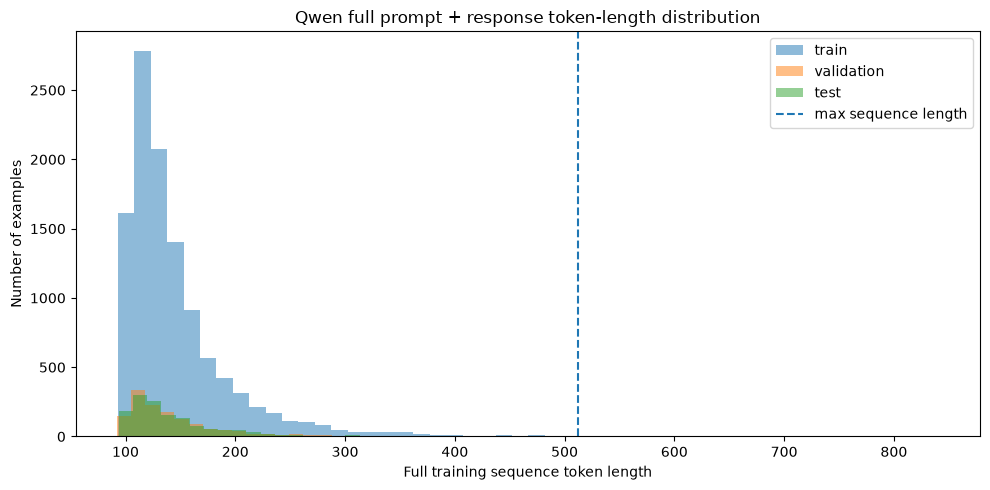

In [11]:
plt.figure(figsize=(10, 5))
for split_name, df in [("train", qwen_train_features), ("validation", qwen_val_features), ("test", qwen_test_features)]:
    plt.hist(df["full_token_len"], bins=50, alpha=0.5, label=split_name)
plt.axvline(MAX_SEQ_LENGTH, linestyle="--", label="max sequence length")
plt.xlabel("Full training sequence token length")
plt.ylabel("Number of examples")
plt.title("Qwen full prompt + response token-length distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "qwen_full_token_length_distribution.png", dpi=200)
plt.show()

## 13. Load Qwen model with optional 4-bit quantization

In [12]:
if USE_4BIT:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    )
else:
    quantization_config = None

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype="auto",
    trust_remote_code=True,
    quantization_config=quantization_config,
)

model.config.use_cache = False

if USE_4BIT:
    model = prepare_model_for_kbit_training(model)

print("Loaded model:", MODEL_NAME)

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loaded model: Qwen/Qwen2.5-1.5B-Instruct


In [13]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.8.0+cu128
12.8
NVIDIA GeForce RTX 4090


In [45]:
!pip install -U "transformers==4.57.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 62.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 8.3 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.26.0
    Uninstalling huggingface_hub-1.26.0:
      Successfully uninstalled huggingface_hub-1.26.0
  Attempting uninstall: transformers━━━━━━━━━━━━ 0/2 [huggingface-hub]
    Found existing installation: transformers 5.14.12m0/2 [huggingface-hub]
    Uninstalling transformers-5.14.1:╺━━━━━━━━━━━━━━━━━━━ 1/2 [transformers]
      Successfully uninstalled transformers-5.14.1━━━━━━━━━━━━━━━━ 1/2 [transformers]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers] [transformers]


## 14. Add LoRA adapters

In [14]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
parameter_info = {
    "total_parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "trainable_percentage": float(100 * trainable_params / total_params),
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
}
with open(OUTPUT_DIR / "analysis" / "qwen_lora_parameter_count.json", "w", encoding="utf-8") as f:
    json.dump(parameter_info, f, indent=2, ensure_ascii=False)
print(json.dumps(parameter_info, indent=2))

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
{
  "total_parameters": 907081216,
  "trainable_parameters": 18464768,
  "trainable_percentage": 2.0356245586723736,
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05
}


## 15. Build causal-LM dataset with prompt masking

For decoder-only models, the loss should be applied mainly to the assistant answer, not the instruction prompt. This cell masks prompt tokens using `-100`.

In [15]:
class QwenInstructionDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        input_text = str(row[INPUT_COL])
        target_text = str(row[TARGET_COL])

        prompt_text = get_prompt_text(input_text)
        full_text = get_full_training_text(input_text, target_text)

        prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
        full = tokenizer(full_text, add_special_tokens=False, truncation=True, max_length=MAX_SEQ_LENGTH)
        input_ids = full["input_ids"]
        attention_mask = full["attention_mask"]
        labels = input_ids.copy()

        prompt_len = min(len(prompt_ids), len(labels))
        labels[:prompt_len] = [-100] * prompt_len

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }

class CausalDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        input_ids, attention_mask, labels = [], [], []
        for f in features:
            pad_len = max_len - len(f["input_ids"])
            input_ids.append(torch.cat([f["input_ids"], torch.full((pad_len,), tokenizer.pad_token_id, dtype=torch.long)]))
            attention_mask.append(torch.cat([f["attention_mask"], torch.zeros(pad_len, dtype=torch.long)]))
            labels.append(torch.cat([f["labels"], torch.full((pad_len,), -100, dtype=torch.long)]))
        return {
            "input_ids": torch.stack(input_ids),
            "attention_mask": torch.stack(attention_mask),
            "labels": torch.stack(labels),
        }

train_dataset = QwenInstructionDataset(train_df)
val_dataset = QwenInstructionDataset(val_df)
data_collator = CausalDataCollator(tokenizer)

sample = train_dataset[0]
print("input_ids length:", len(sample["input_ids"]))
print("number of label tokens used for loss:", int((sample["labels"] != -100).sum()))
print("number of prompt tokens masked:", int((sample["labels"] == -100).sum()))

input_ids length: 130
number of label tokens used for loss: 23
number of prompt tokens masked: 107


## 16. Metric functions

These match the ByT5, T5, and BiLSTM notebooks for fair comparison.

In [2]:
chrf_metric = CHRF(word_order=2)
PUNCTUATION_MARKS = set(list(".,!?;:"))

def normalize_for_metric(text: str) -> str:
    return re.sub(r"\s+", " ", str(text)).strip()

def exact_match_score(preds: List[str], refs: List[str]) -> float:
    return float(np.mean([normalize_for_metric(p) == normalize_for_metric(r) for p, r in zip(preds, refs)])) if refs else 0.0

def word_accuracy(preds: List[str], refs: List[str]) -> float:
    total = 0
    correct = 0
    for pred, ref in zip(preds, refs):
        pred_words = normalize_for_metric(pred).split()
        ref_words = normalize_for_metric(ref).split()
        max_len = max(len(pred_words), len(ref_words))
        if max_len == 0:
            continue
        total += max_len
        for i in range(max_len):
            pw = pred_words[i] if i < len(pred_words) else None
            rw = ref_words[i] if i < len(ref_words) else None
            correct += int(pw == rw)
    return correct / total if total else 0.0

def get_punctuation_sequence(text: str) -> List[str]:
    return [ch for ch in str(text) if ch in PUNCTUATION_MARKS]

def punctuation_prf(preds: List[str], refs: List[str]) -> Dict[str, float]:
    y_true, y_pred = [], []
    for pred, ref in zip(preds, refs):
        pred_p = get_punctuation_sequence(pred)
        ref_p = get_punctuation_sequence(ref)
        max_len = max(len(pred_p), len(ref_p))
        for i in range(max_len):
            y_pred.append(pred_p[i] if i < len(pred_p) else "NONE")
            y_true.append(ref_p[i] if i < len(ref_p) else "NONE")
    if not y_true:
        return {"punct_precision": 0.0, "punct_recall": 0.0, "punct_f1": 0.0, "punct_accuracy": 0.0}
    labels = sorted(list(PUNCTUATION_MARKS))
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    return {
        "punct_precision": float(precision),
        "punct_recall": float(recall),
        "punct_f1": float(f1),
        "punct_accuracy": float(accuracy_score(y_true, y_pred)),
    }

def capitalization_labels(text: str) -> List[int]:
    return [1 if ch.isupper() else 0 for ch in str(text) if ch.isalpha()]

def capitalization_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    y_true, y_pred = [], []
    for pred, ref in zip(preds, refs):
        pred_caps = capitalization_labels(pred)
        ref_caps = capitalization_labels(ref)
        max_len = max(len(pred_caps), len(ref_caps))
        for i in range(max_len):
            y_pred.append(pred_caps[i] if i < len(pred_caps) else 0)
            y_true.append(ref_caps[i] if i < len(ref_caps) else 0)
    if not y_true:
        return {"capitalization_accuracy": 0.0, "capitalization_f1": 0.0}
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {"capitalization_accuracy": float(accuracy_score(y_true, y_pred)), "capitalization_f1": float(f1)}

def compute_text_metrics(preds: List[str], refs: List[str]) -> Dict[str, float]:
    preds_norm = [normalize_for_metric(p) for p in preds]
    refs_norm = [normalize_for_metric(r) for r in refs]
    metrics = {
        "cer": float(cer(refs_norm, preds_norm)),
        "wer": float(wer(refs_norm, preds_norm)),
        "chrf": float(chrf_metric.corpus_score(preds_norm, [refs_norm]).score),
        "exact_match": exact_match_score(preds_norm, refs_norm),
        "word_accuracy": word_accuracy(preds_norm, refs_norm),
    }
    metrics.update(punctuation_prf(preds_norm, refs_norm))
    metrics.update(capitalization_metrics(preds_norm, refs_norm))
    return metrics

## 17. Qwen output cleanup and instruction-following analysis

In [18]:
EXPLANATION_PATTERNS = [
    "here is", "corrected", "the corrected", "output:", "answer:", "response:",
    "voici", "sentence:", "standardized:"
]

def clean_qwen_output(text: str) -> str:
    text = str(text).strip()
    # Keep first non-empty line if model produces explanations.
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    if len(lines) > 1:
        # Prefer the last line when earlier lines are explanatory.
        text = lines[-1]
    # Remove common prefixes.
    text = re.sub(r"^(Output|Answer|Response|Corrected sentence|Standardized)\s*:\s*", "", text, flags=re.I).strip()
    return text

def has_extra_explanation(text: str) -> bool:
    lower = str(text).lower()
    return any(p in lower for p in EXPLANATION_PATTERNS)

def instruction_following_analysis(raw_preds: List[str], cleaned_preds: List[str]) -> Dict[str, Any]:
    n = len(raw_preds)
    if n == 0:
        return {"num_outputs": 0}
    extra_count = sum(has_extra_explanation(x) for x in raw_preds)
    changed_by_cleanup = sum(str(a).strip() != str(b).strip() for a, b in zip(raw_preds, cleaned_preds))
    return {
        "num_outputs": n,
        "extra_explanation_count": int(extra_count),
        "extra_explanation_rate": float(extra_count / n),
        "changed_by_cleanup_count": int(changed_by_cleanup),
        "changed_by_cleanup_rate": float(changed_by_cleanup / n),
    }

## 18. Generation function and inference-time tracking

In [9]:
def generate_one(input_text: str) -> Dict[str, Any]:
    messages = build_messages(input_text, None)
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([prompt_text], return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(model.device)
    prompt_len = model_inputs["input_ids"].shape[-1]
    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    new_tokens = generated_ids[0][prompt_len:]
    raw_output = tokenizer.decode(new_tokens, skip_special_tokens=True)
    cleaned = clean_qwen_output(raw_output)
    return {
        "prompt_text": prompt_text,
        "raw_prediction": raw_output,
        "prediction": cleaned,
        "prompt_token_len": int(prompt_len),
        "generated_token_len": int(len(new_tokens)),
    }

def generate_predictions_for_df(df: pd.DataFrame, split_name: str, sample_limit=None) -> pd.DataFrame:
    model.eval()
    use_df = df.copy()
    if sample_limit is not None:
        use_df = use_df.head(sample_limit).copy()

    rows = []
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inference_start = time.time()

    for _, row in use_df.iterrows():
        result = generate_one(row[INPUT_COL])
        rows.append({
            "split": split_name,
            "id": row[ID_COL],
            "input_text": row[INPUT_COL],
            "target_text": row[TARGET_COL],
            **result,
        })

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    total_seconds = time.time() - inference_start

    pred_df = pd.DataFrame(rows)
    pred_df["sentence_cer"] = [cer([r], [p]) for p, r in zip(pred_df["prediction"], pred_df["target_text"])]
    pred_df["sentence_wer"] = [wer([r], [p]) for p, r in zip(pred_df["prediction"], pred_df["target_text"])]
    pred_df["exact_match"] = [normalize_for_metric(p) == normalize_for_metric(r) for p, r in zip(pred_df["prediction"], pred_df["target_text"])]
    pred_df["response_char_len"] = pred_df["prediction"].apply(len)
    pred_df["reference_char_len"] = pred_df["target_text"].apply(len)
    pred_df["response_reference_length_diff"] = pred_df["response_char_len"] - pred_df["reference_char_len"]
    pred_df["has_extra_explanation"] = pred_df["raw_prediction"].apply(has_extra_explanation)

    timing = {
        "split": split_name,
        "num_sentences": len(pred_df),
        "total_inference_seconds": total_seconds,
        "average_inference_seconds_per_sentence": total_seconds / len(pred_df) if len(pred_df) else None,
        "sentences_per_second": len(pred_df) / total_seconds if total_seconds > 0 else None,
    }

    pred_df.to_csv(OUTPUT_DIR / "predictions" / f"{split_name}_predictions.csv", index=False, encoding="utf-8")
    with open(OUTPUT_DIR / f"inference_time_{split_name}.json", "w", encoding="utf-8") as f:
        json.dump(timing, f, indent=2, ensure_ascii=False)

    print(json.dumps(timing, indent=2))
    return pred_df

def evaluate_prediction_dataframe(pred_df: pd.DataFrame, split_name: str) -> Dict[str, Any]:
    metrics = compute_text_metrics(pred_df["prediction"].tolist(), pred_df["target_text"].tolist())
    metrics["split"] = split_name
    metrics["num_examples"] = len(pred_df)
    metrics["avg_generated_token_len"] = float(pred_df["generated_token_len"].mean()) if len(pred_df) else 0
    metrics["avg_prompt_token_len"] = float(pred_df["prompt_token_len"].mean()) if len(pred_df) else 0
    metrics["extra_explanation_rate"] = float(pred_df["has_extra_explanation"].mean()) if len(pred_df) else 0
    metrics["avg_response_reference_length_diff"] = float(pred_df["response_reference_length_diff"].mean()) if len(pred_df) else 0
    return metrics

NameError: name 'Dict' is not defined

## 19. Validation generation callback for comparable curves

This makes validation CER/WER/chrF curves similar to the ByT5/T5/BiLSTM notebooks.

In [20]:
class ValidationGenerationCallback(TrainerCallback):
    def __init__(self, validation_df: pd.DataFrame):
        self.validation_df = validation_df
        self.rows = []

    def on_epoch_end(self, args, state, control, **kwargs):
        epoch = int(round(state.epoch)) if state.epoch is not None else len(self.rows) + 1
        val_pred = generate_predictions_for_df(self.validation_df, f"validation_epoch_{epoch}", sample_limit=CURVE_EVAL_SAMPLE_LIMIT)
        val_metrics = evaluate_prediction_dataframe(val_pred, "validation")
        row = {"epoch": epoch}
        for k, v in val_metrics.items():
            if isinstance(v, (int, float)):
                row[f"eval_{k}"] = v
        self.rows.append(row)
        pd.DataFrame(self.rows).to_csv(OUTPUT_DIR / "validation_generation_metrics_by_epoch.csv", index=False, encoding="utf-8")
        return control

validation_generation_callback = ValidationGenerationCallback(val_df)

## 20. Training arguments

In [21]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    logging_strategy="steps",
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    fp16=False,
    bf16=torch.cuda.is_available(),
    optim="paged_adamw_8bit" if USE_4BIT else "adamw_torch",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    callbacks=[validation_generation_callback],
)

## 21. Train Qwen and record training time

In [22]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

training_start_time = time.time()
training_start_readable = datetime.now().isoformat()

train_result = trainer.train()

if torch.cuda.is_available():
    torch.cuda.synchronize()

training_end_time = time.time()
training_end_readable = datetime.now().isoformat()
training_seconds = training_end_time - training_start_time

training_time_info = {
    "training_start_time": training_start_readable,
    "training_end_time": training_end_readable,
    "training_seconds": training_seconds,
    "training_minutes": training_seconds / 60,
    "training_hours": training_seconds / 3600,
    "peak_gpu_memory_gb": (torch.cuda.max_memory_allocated() / (1024 ** 3)) if torch.cuda.is_available() else None,
}

with open(OUTPUT_DIR / "training_time.json", "w", encoding="utf-8") as f:
    json.dump(training_time_info, f, indent=2, ensure_ascii=False)

trainer.save_model(str(OUTPUT_DIR / "best_lora_adapter"))
tokenizer.save_pretrained(str(OUTPUT_DIR / "best_lora_adapter"))

log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv(OUTPUT_DIR / "training_log.csv", index=False, encoding="utf-8")
print(json.dumps(training_time_info, indent=2))
display(log_df.tail())

Epoch,Training Loss,Validation Loss
1,0.311100,0.294836
2,0.181500,0.240339
3,0.103700,0.241908


{
  "split": "validation_epoch_1",
  "num_sentences": 100,
  "total_inference_seconds": 230.48709726333618,
  "average_inference_seconds_per_sentence": 2.3048709726333616,
  "sentences_per_second": 0.4338637658564808
}
{
  "split": "validation_epoch_2",
  "num_sentences": 100,
  "total_inference_seconds": 230.15805768966675,
  "average_inference_seconds_per_sentence": 2.3015805768966673,
  "sentences_per_second": 0.4344840280796723
}
{
  "split": "validation_epoch_3",
  "num_sentences": 100,
  "total_inference_seconds": 229.8759355545044,
  "average_inference_seconds_per_sentence": 2.298759355545044,
  "sentences_per_second": 0.43501726163193644
}
{
  "training_start_time": "2026-08-05T09:05:06.811592",
  "training_end_time": "2026-08-05T11:08:28.574308",
  "training_seconds": 7401.762727737427,
  "training_minutes": 123.36271212895711,
  "training_hours": 2.056045202149285,
  "peak_gpu_memory_gb": 4.022692680358887
}


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
102,0.0982,0.711231,0.000006,2.919740,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,0.1006,0.532794,0.000004,2.948662,2040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104,0.1037,0.706725,0.000002,2.977585,2060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,3.000000,2076,0.241908,70.6198,19.584,9.799,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,3.000000,2076,NaN,NaN,NaN,NaN,7401.4013,4.485,0.28,4.519703e+16,0.269686


## 22. Plot training and validation loss

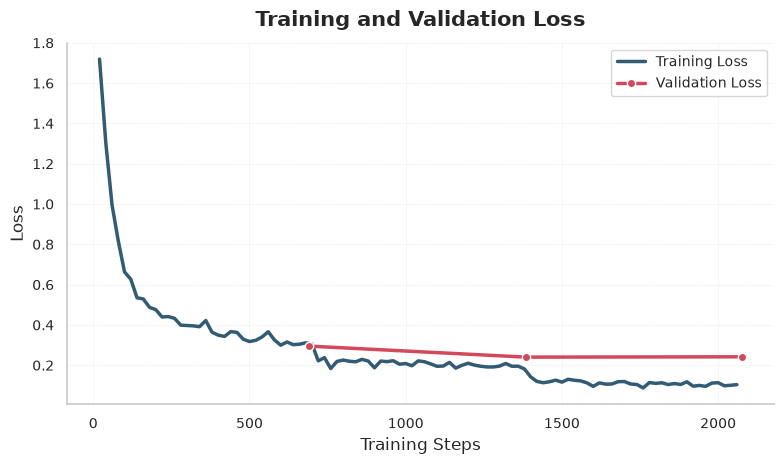

In [53]:
def plot_loss_curves(log_df: pd.DataFrame):
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(8, 4.8))

    # Training loss
    if "loss" in log_df.columns:
        train_loss_df = log_df.dropna(subset=["loss"])

        if not train_loss_df.empty:
            plt.plot(
                train_loss_df["step"],
                train_loss_df["loss"],
                color="#1B4965",
                linewidth=2.5,
                alpha=0.9,
                label="Training Loss"
            )

    # Validation loss
    if "eval_loss" in log_df.columns:
        eval_loss_df = log_df.dropna(subset=["eval_loss"])

        if not eval_loss_df.empty:
            plt.plot(
                eval_loss_df["step"],
                eval_loss_df["eval_loss"],
                color="#D1495B",
                linewidth=2.5,
                marker="o",
                markersize=6,
                markeredgecolor="white",
                markeredgewidth=1,
                label="Validation Loss"
            )

    # Title
    plt.title(
        "Training and Validation Loss",
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    # Axis labels
    plt.xlabel(
        "Training Steps",
        fontsize=12
    )

    plt.ylabel(
        "Loss",
        fontsize=12
    )

    # Tick formatting
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Legend
    plt.legend(
        fontsize=10,
        frameon=True,
        fancybox=True,
        loc="best"
    )

    # Grid
    plt.grid(
        linestyle="--",
        linewidth=0.5,
        alpha=0.35
    )

    # Remove unnecessary borders
    sns.despine()

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "plots" / "loss_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

plot_loss_curves(log_df)

## 23. Plot validation metric curves

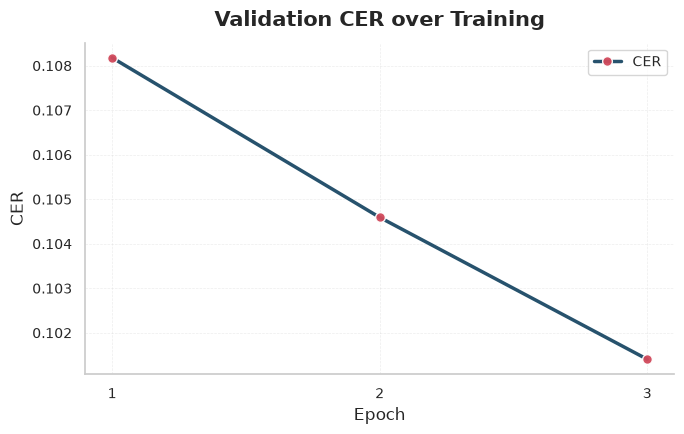

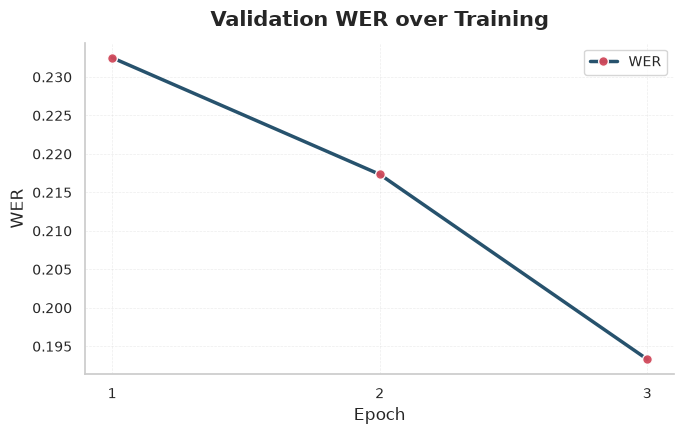

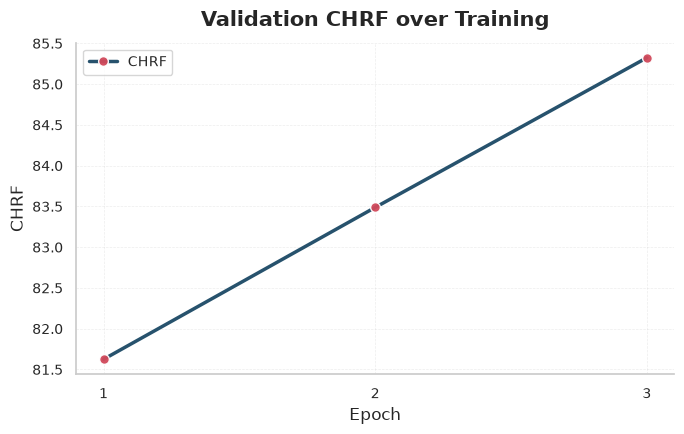

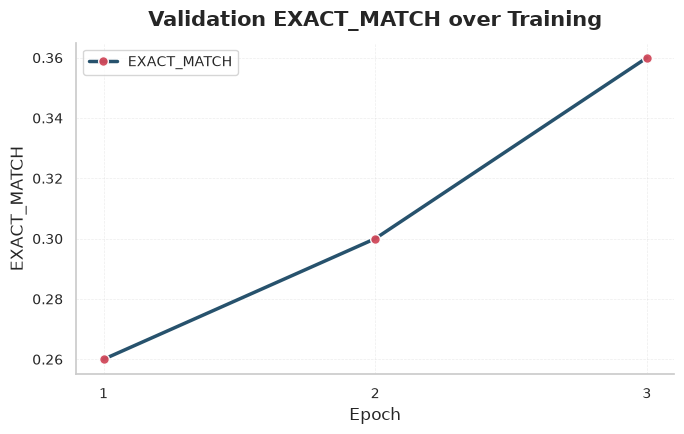

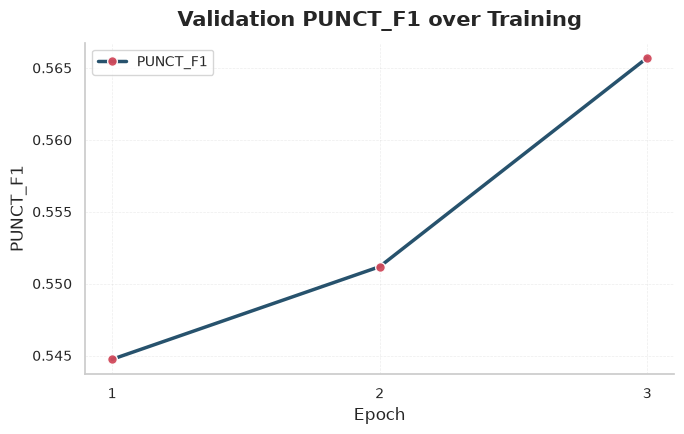

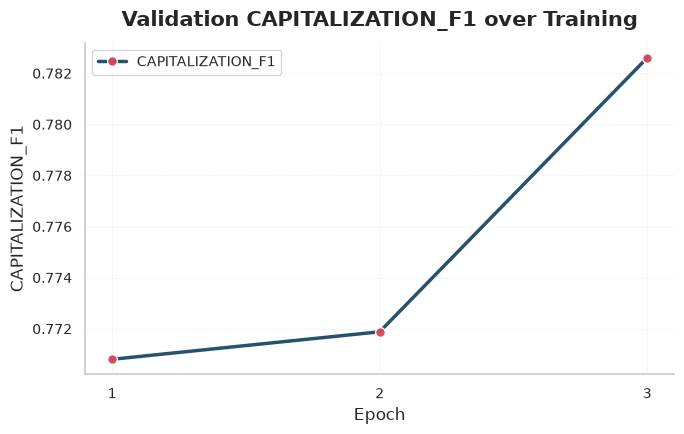

In [54]:
def plot_eval_metric(curve_df: pd.DataFrame, metric_name: str):
    col = f"eval_{metric_name}"

    if col not in curve_df.columns:
        print(f"Metric not found: {col}")
        return

    plt.figure(figsize=(7, 4.5))

    plt.plot(
        curve_df["epoch"],
        curve_df[col],
        color="#1B4965",
        linewidth=2.5,
        marker="o",
        markersize=7,
        markerfacecolor="#D1495B",
        markeredgecolor="white",
        markeredgewidth=1,
        alpha=0.95,
        label=metric_name.upper()
    )

    plt.title(
        f"Validation {metric_name.upper()} over Training",
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    plt.xlabel(
        "Epoch",
        fontsize=12
    )

    plt.ylabel(
        metric_name.upper(),
        fontsize=12
    )

    plt.xticks(
        curve_df["epoch"],
        fontsize=10
    )

    plt.yticks(fontsize=10)

    plt.grid(
        linestyle="--",
        linewidth=0.5,
        alpha=0.35
    )

    plt.legend(
        fontsize=10,
        frameon=True,
        fancybox=True,
        loc="best"
    )

    sns.despine()

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "plots" / f"validation_{metric_name}_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


for metric in [
    "cer",
    "wer",
    "chrf",
    "exact_match",
    "punct_f1",
    "capitalization_f1"
]:
    plot_eval_metric(curve_df, metric)

In [47]:
EVAL_SAMPLE_LIMIT = None

In [31]:
val_predictions = generate_predictions_for_df(
    val_df,
    "validation",
    sample_limit=None
)

test_predictions = generate_predictions_for_df(
    test_df,
    "test",
    sample_limit=None
)

metrics_val = evaluate_prediction_dataframe(val_predictions, "validation")
metrics_test = evaluate_prediction_dataframe(test_predictions, "test")

{
  "split": "validation",
  "num_sentences": 1383,
  "total_inference_seconds": 3084.4863698482513,
  "average_inference_seconds_per_sentence": 2.2302866014810205,
  "sentences_per_second": 0.4483728680143398
}
{
  "split": "test",
  "num_sentences": 1383,
  "total_inference_seconds": 3024.373938560486,
  "average_inference_seconds_per_sentence": 2.1868213583228386,
  "sentences_per_second": 0.45728472341560644
}


In [32]:
all_metrics = [metrics_val, metrics_test]
metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(OUTPUT_DIR / "all_split_metrics.csv", index=False, encoding="utf-8")
for name, metrics in [("validation", metrics_val), ("test", metrics_test)]:
    with open(OUTPUT_DIR / f"metrics_{name}.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
display(metrics_df)

,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,split,num_examples,avg_generated_token_len,avg_prompt_token_len,extra_explanation_rate,avg_response_reference_length_diff
0,0.062695,0.168207,87.260294,0.317426,0.750419,0.663868,0.428945,0.497337,0.638253,0.981029,0.805425,validation,1383,29.604483,115.061461,0.0,-2.804049
1,0.069335,0.174200,86.569149,0.323933,0.750416,0.619018,0.391429,0.451635,0.626234,0.982438,0.826669,test,1383,29.702820,115.207520,0.0,-3.116414


## 24. Final evaluation on train, validation, and test

In [28]:
# train_predictions = generate_predictions_for_df(train_df, "train", sample_limit=EVAL_SAMPLE_LIMIT)
# val_predictions = generate_predictions_for_df(val_df, "validation", sample_limit=EVAL_SAMPLE_LIMIT)
# test_predictions = generate_predictions_for_df(test_df, "test", sample_limit=EVAL_SAMPLE_LIMIT)

# metrics_train = evaluate_prediction_dataframe(train_predictions, "train")
# metrics_val = evaluate_prediction_dataframe(val_predictions, "validation")
# metrics_test = evaluate_prediction_dataframe(test_predictions, "test")

# all_metrics = [metrics_train, metrics_val, metrics_test]
# metrics_df = pd.DataFrame(all_metrics)
# metrics_df.to_csv(OUTPUT_DIR / "all_split_metrics.csv", index=False, encoding="utf-8")
# for name, metrics in [("train", metrics_train), ("validation", metrics_val), ("test", metrics_test)]:
#     with open(OUTPUT_DIR / f"metrics_{name}.json", "w", encoding="utf-8") as f:
#         json.dump(metrics, f, indent=2, ensure_ascii=False)
# display(metrics_df)
# train_predictions = generate_predictions_for_df(
#     train_df, "train", sample_limit=EVAL_SAMPLE_LIMIT
# )

val_predictions = generate_predictions_for_df(
    val_df, "validation", sample_limit=EVAL_SAMPLE_LIMIT
)

test_predictions = generate_predictions_for_df(
    test_df, "test", sample_limit=EVAL_SAMPLE_LIMIT
)

# metrics_train = evaluate_prediction_data_dataframe(train_predictions, "train")

metrics_val = evaluate_prediction_data_dataframe(
    val_predictions, "validation"
)

metrics_test = evaluate_prediction_data_dataframe(
    test_predictions, "test"
)

# all_metrics = [metrics_train, metrics_val, metrics_test]

all_metrics = [metrics_val, metrics_test]

metrics_df = pd.DataFrame(all_metrics)

metrics_df.to_csv(
    OUTPUT_DIR / "all_split_metrics.csv",
    index=False,
    encoding="utf-8"
)

# Don't save train metrics
# for name, metrics in [("train", metrics_train), ("validation", metrics_val), ("test", metrics_test)]:

for name, metrics in [
    ("validation", metrics_val),
    ("test", metrics_test)
]:
    with open(
        OUTPUT_DIR / f"metrics_{name}.json",
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

display(metrics_df)

## 25. Save timing summary

In [34]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

timing_summary = {
    "training": training_time_info,
    # "inference_train": load_json(OUTPUT_DIR / "inference_time_train.json"),
    "inference_validation": load_json(OUTPUT_DIR / "inference_time_validation.json"),
    "inference_test": load_json(OUTPUT_DIR / "inference_time_test.json"),
}
with open(OUTPUT_DIR / "timing_summary.json", "w", encoding="utf-8") as f:
    json.dump(timing_summary, f, indent=2, ensure_ascii=False)
print(json.dumps(timing_summary, indent=2))

{
  "training": {
    "training_start_time": "2026-08-05T09:05:06.811592",
    "training_end_time": "2026-08-05T11:08:28.574308",
    "training_seconds": 7401.762727737427,
    "training_minutes": 123.36271212895711,
    "training_hours": 2.056045202149285,
    "peak_gpu_memory_gb": 4.022692680358887
  },
  "inference_validation": {
    "split": "validation",
    "num_sentences": 1383,
    "total_inference_seconds": 3084.4863698482513,
    "average_inference_seconds_per_sentence": 2.2302866014810205,
    "sentences_per_second": 0.4483728680143398
  },
  "inference_test": {
    "split": "test",
    "num_sentences": 1383,
    "total_inference_seconds": 3024.373938560486,
    "average_inference_seconds_per_sentence": 2.1868213583228386,
    "sentences_per_second": 0.45728472341560644
  }
}


## 26. Qwen-specific generation behavior analysis

In [35]:
def qwen_generation_behavior_analysis(pred_df: pd.DataFrame, split_name: str) -> Dict[str, Any]:
    raw_preds = pred_df["raw_prediction"].tolist()
    cleaned_preds = pred_df["prediction"].tolist()
    info = instruction_following_analysis(raw_preds, cleaned_preds)
    info.update({
        "split": split_name,
        "avg_prompt_token_len": float(pred_df["prompt_token_len"].mean()),
        "avg_generated_token_len": float(pred_df["generated_token_len"].mean()),
        "avg_response_char_len": float(pred_df["response_char_len"].mean()),
        "avg_reference_char_len": float(pred_df["reference_char_len"].mean()),
        "avg_response_reference_length_diff": float(pred_df["response_reference_length_diff"].mean()),
        "overlong_response_rate": float((pred_df["response_reference_length_diff"] > 20).mean()),
        "very_short_response_rate": float((pred_df["response_char_len"] < (0.5 * pred_df["reference_char_len"])).mean()),
    })
    return info

qwen_behavior_test = qwen_generation_behavior_analysis(test_predictions, "test")
with open(OUTPUT_DIR / "analysis" / "qwen_generation_behavior_test.json", "w", encoding="utf-8") as f:
    json.dump(qwen_behavior_test, f, indent=2, ensure_ascii=False)
print(json.dumps(qwen_behavior_test, indent=2))

{
  "num_outputs": 1383,
  "extra_explanation_count": 0,
  "extra_explanation_rate": 0.0,
  "changed_by_cleanup_count": 0,
  "changed_by_cleanup_rate": 0.0,
  "split": "test",
  "avg_prompt_token_len": 115.20751988430948,
  "avg_generated_token_len": 29.702819956616054,
  "avg_response_char_len": 89.14533622559652,
  "avg_reference_char_len": 92.26174981923354,
  "avg_response_reference_length_diff": -3.116413593637021,
  "overlong_response_rate": 0.0014461315979754157,
  "very_short_response_rate": 0.0014461315979754157
}


## 27. Plot generated length vs reference length

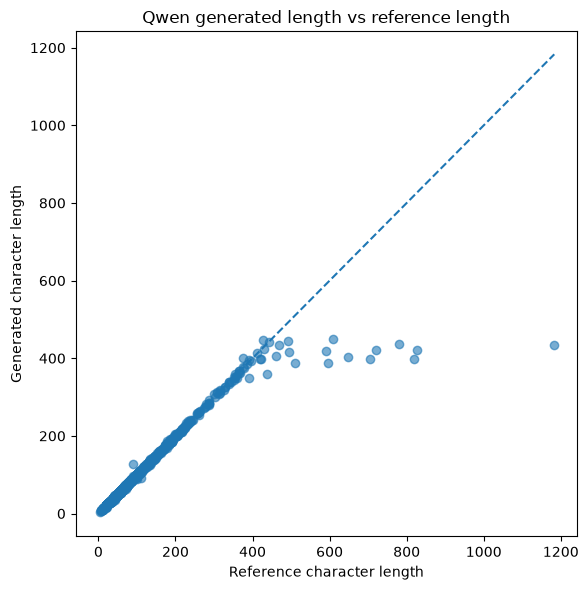

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(test_predictions["reference_char_len"], test_predictions["response_char_len"], alpha=0.6)
max_len = max(test_predictions["reference_char_len"].max(), test_predictions["response_char_len"].max())
plt.plot([0, max_len], [0, max_len], linestyle="--")
plt.xlabel("Reference character length")
plt.ylabel("Generated character length")
plt.title("Qwen generated length vs reference length")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "qwen_generated_vs_reference_length.png", dpi=200)
plt.show()

## 28. Error category analysis

In [3]:
import pandas as pd
import re
from pathlib import Path

# =========================================================
# 1. FILES
# =========================================================

INPUT_FILE = Path(
    "results/qwen/analysis/test_error_categories.csv"
)
OUTPUT_DIR = Path(
    "results/qwen/analysis/simple_error_analysis"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "capitalization_punctuation_analysis.csv"
COUNTS_FILE = OUTPUT_DIR / "capitalization_punctuation_counts.csv"


# =========================================================
# 2. LOAD DATA
# =========================================================

source = pd.read_csv(INPUT_FILE)

df = source[
    [
        "split",
        "input_text",
        "target_text",
        "prediction",
        "sentence_cer",
        "sentence_wer",
        "exact_match"
    ]
].copy()

df["target_text"] = df["target_text"].fillna("").astype(str)
df["prediction"] = df["prediction"].fillna("").astype(str)

print("Number of test examples:", len(df))


# =========================================================
# 3. CORRECT
# =========================================================

df["correct"] = (
    df["target_text"] == df["prediction"]
)


# =========================================================
# 4. PUNCTUATION ERROR
# =========================================================

# Punctuation used in your restoration task
PUNCTUATION = set(".,?!:;")


def get_punctuation(text):
    """
    Return punctuation marks in their original order.
    """

    return [
        char
        for char in text
        if char in PUNCTUATION
    ]


def has_punctuation_error(target, prediction):
    """
    True when the punctuation sequence differs.
    """

    return (
        get_punctuation(target)
        != get_punctuation(prediction)
    )


df["punctuation_error"] = [
    has_punctuation_error(target, prediction)
    for target, prediction in zip(
        df["target_text"],
        df["prediction"]
    )
]


# =========================================================
# 5. CAPITALIZATION ERROR
# =========================================================

WORD_PATTERN = r"[^\W\d_]+(?:['’][^\W\d_]+)*"


def get_words(text):
    return re.findall(
        WORD_PATTERN,
        text,
        flags=re.UNICODE
    )


def has_capitalization_error(target, prediction):
    """
    Detect capitalization differences when the underlying
    word is otherwise the same.

    Example:

        Target:     Mauritius
        Prediction: mauritius

        -> capitalization error

    But:

        Target:     dan
        Prediction: da

        -> NOT capitalization error
    """

    target_words = get_words(target)
    prediction_words = get_words(prediction)

    for target_word, prediction_word in zip(
        target_words,
        prediction_words
    ):

        if (
            target_word.casefold()
            ==
            prediction_word.casefold()
            and
            target_word != prediction_word
        ):
            return True

    return False


df["capitalization_error"] = [
    has_capitalization_error(target, prediction)
    for target, prediction in zip(
        df["target_text"],
        df["prediction"]
    )
]


# =========================================================
# 6. FINAL ERROR CATEGORY
# =========================================================

def classify(row):

    # Exact match
    if row["correct"]:
        return "correct"

    punctuation = row["punctuation_error"]
    capitalization = row["capitalization_error"]

    if punctuation and capitalization:
        return "capitalization_error;punctuation_error"

    if punctuation:
        return "punctuation_error"

    if capitalization:
        return "capitalization_error"

    # A prediction may have other normalization differences,
    # but we are deliberately NOT analysing those here.
    return "normalization error"


df["error_category"] = df.apply(
    classify,
    axis=1
)


# =========================================================
# 7. COUNTS
# =========================================================

category_counts = (
    df["error_category"]
    .value_counts()
    .rename_axis("error_category")
    .reset_index(name="count")
)


# =========================================================
# 8. DISPLAY
# =========================================================

print("\n========================================")
print("ERROR CATEGORY COUNTS")
print("========================================")

display(category_counts)


# =========================================================
# 9. DISPLAY ONLY THE FOUR CATEGORIES
# =========================================================

main_categories = [
    "correct",
    "capitalization_error",
    "punctuation_error",
    "capitalization_error;punctuation_error"
]

main_counts = (
    category_counts[
        category_counts["error_category"].isin(main_categories)
    ]
    .set_index("error_category")
    .reindex(main_categories, fill_value=0)
    .reset_index()
)

print("\n========================================")
print("MAIN ANALYSIS")
print("========================================")

display(main_counts)


# =========================================================
# 10. SAVE
# =========================================================

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8"
)

main_counts.to_csv(
    COUNTS_FILE,
    index=False,
    encoding="utf-8"
)


print("\n========================================")
print("SAVED")
print("========================================")

print(OUTPUT_FILE)
print(COUNTS_FILE)

Number of test examples: 1383

ERROR CATEGORY COUNTS


,error_category,count
0,correct,448
1,capitalization_error;punctuation_error,388
2,punctuation_error,307
3,normalization error,206
4,capitalization_error,34



MAIN ANALYSIS


,error_category,count
0,correct,448
1,capitalization_error,34
2,punctuation_error,307
3,capitalization_error;punctuation_error,388



SAVED
results/qwen/analysis/simple_error_analysis/capitalization_punctuation_analysis.csv
results/qwen/analysis/simple_error_analysis/capitalization_punctuation_counts.csv


In [2]:
!pip install pandas

  Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.0 MB)


## 29. Plot error categories

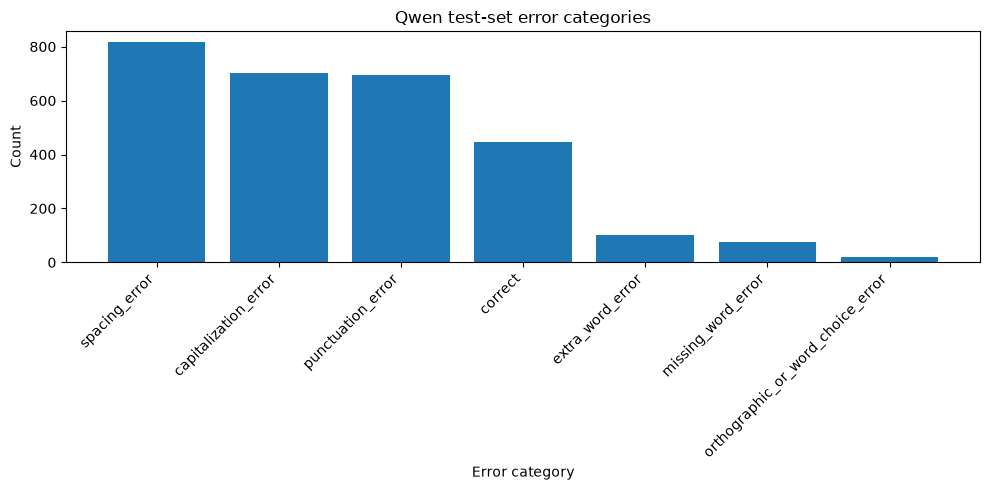

In [41]:
plt.figure(figsize=(10, 5))
plt.bar(error_counts["error_category"], error_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Error category")
plt.ylabel("Count")
plt.title("Qwen test-set error categories")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "test_error_categories.png", dpi=200)
plt.show()

In [2]:
# =========================================================
# SAVE ALL EXAMPLES WITH THEIR ERROR CATEGORY
# =========================================================

ALL_EXAMPLES_FILE = (
    OUTPUT_DIR /
    "all_error_category_examples.csv"
)

# Rename the temporary category to the final thesis category
df_export = df.copy()

df_export["error_category"] = df_export["error_category"].replace(
    {
        "other_unanalysed_difference": "normalization_error"
    }
)

# Keep the useful columns
df_export = df_export[
    [
        "split",
        "input_text",
        "target_text",
        "prediction",
        "sentence_cer",
        "sentence_wer",
        "exact_match",
        "correct",
        "punctuation_error",
        "capitalization_error",
        "error_category"
    ]
]

# Save all 1,383 examples
df_export.to_csv(
    ALL_EXAMPLES_FILE,
    index=False,
    encoding="utf-8"
)

print("\n========================================")
print("ALL ERROR CATEGORY EXAMPLES SAVED")
print("========================================")

print("Number of examples:", len(df_export))
print("File:")
print(ALL_EXAMPLES_FILE)


ALL ERROR CATEGORY EXAMPLES SAVED
Number of examples: 1383
File:
results/qwen/analysis/simple_error_analysis/all_error_category_examples.csv


Sentence-length analysis

In [4]:
import pandas as pd

from pathlib import Path


# ==========================================================
# 1. LOAD TEST DATA
# ==========================================================

INPUT_FILE = Path(
   "results/qwen/predictions/test_predictions.csv"
)

OUTPUT_DIR = Path(
    "results_/qwen/analysis/sentence_len_analysis"
)


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INPUT_FILE)

print("Number of test examples:", len(df))


# ==========================================================
# 2. DEFINE COLUMN NAMES
# ==========================================================

REFERENCE_COLUMN = "target_text"
PREDICTION_COLUMN = "prediction"

# Change PREDICTION_COLUMN only if your CSV uses another name,
# such as "predicted_text", "prediction", or "generated_text".

required_columns = {
    REFERENCE_COLUMN,
    PREDICTION_COLUMN
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}\n"
        f"Available columns: {df.columns.tolist()}"
    )


# ==========================================================
# 3. CLEAN PREDICTIONS AND REFERENCES
# ==========================================================

df[REFERENCE_COLUMN] = (
    df[REFERENCE_COLUMN]
    .fillna("")
    .astype(str)
)

df[PREDICTION_COLUMN] = (
    df[PREDICTION_COLUMN]
    .fillna("")
    .astype(str)
)


# ==========================================================
# 4. CALCULATE REFERENCE SENTENCE LENGTH
# ==========================================================

# Sentence length is based on the target/reference text.
# Therefore, the same test example belongs to the same band
# for every model.

df["sentence_length"] = (
    df[REFERENCE_COLUMN]
    .str.split()
    .str.len()
)


# ==========================================================
# 5. CREATE SENTENCE-LENGTH BANDS
# ==========================================================

def sentence_length_band(length):

    if length <= 5:
        return "1–5 words"

    elif length <= 10:
        return "6–10 words"

    elif length <= 20:
        return "11–20 words"

    elif length <= 30:
        return "21–30 words"

    elif length <= 50:
        return "31–50 words"

    elif length <= 100:
        return "51–100 words"

    else:
        return ">100 words"


df["sentence_length_band"] = (
    df["sentence_length"]
    .apply(sentence_length_band)
)


# ==========================================================
# 6. DEFINE BAND ORDER
# ==========================================================

band_order = [
    "1–5 words",
    "6–10 words",
    "11–20 words",
    "21–30 words",
    "31–50 words",
    "51–100 words",
    ">100 words"
]


# ==========================================================
# 7. CALCULATE ALL METRICS FOR EACH LENGTH BAND
# ==========================================================

sentence_length_results = []

for band in band_order:

    band_df = df[
        df["sentence_length_band"] == band
    ].copy()

    if band_df.empty:
        continue

    predictions = (
        band_df[PREDICTION_COLUMN]
        .tolist()
    )

    references = (
        band_df[REFERENCE_COLUMN]
        .tolist()
    )

    # Call the same evaluation function used for all models
    band_metrics = compute_text_metrics(
        predictions,
        references
    )

    sentence_length_results.append({
        "sentence_length_band": band,
        "n": len(band_df),

        "CER": band_metrics["cer"],
        "WER": band_metrics["wer"],
        "chrF++": band_metrics["chrf"],

        "exact_match": band_metrics["exact_match"],
        "word_accuracy": band_metrics["word_accuracy"],

        "punctuation_precision":
            band_metrics["punct_precision"],

        "punctuation_recall":
            band_metrics["punct_recall"],

        "punctuation_F1":
            band_metrics["punct_f1"],

        "punctuation_accuracy":
            band_metrics["punct_accuracy"],

        "capitalisation_accuracy":
            band_metrics["capitalization_accuracy"],

        "capitalisation_F1":
            band_metrics["capitalization_f1"],
    })


sentence_length_analysis = pd.DataFrame(
    sentence_length_results
)


# ==========================================================
# 8. ROUND RESULTS
# ==========================================================

metric_columns = [
    "CER",
    "WER",
    "chrF++",
    "exact_match",
    "word_accuracy",
    "punctuation_precision",
    "punctuation_recall",
    "punctuation_F1",
    "punctuation_accuracy",
    "capitalisation_accuracy",
    "capitalisation_F1"
]

sentence_length_analysis[metric_columns] = (
    sentence_length_analysis[metric_columns]
    .round(4)
)


# ==========================================================
# 9. DISPLAY COMPLETE RESULTS
# ==========================================================

print("=" * 100)
print("TEXT-RESTORATION METRICS BY REFERENCE SENTENCE LENGTH")
print("=" * 100)

display(sentence_length_analysis)


# ==========================================================
# 10. CREATE THESIS-SPECIFIC OUTPUT
# ==========================================================

# This smaller table contains only the metrics needed for
# the input-complexity analysis in the thesis.

thesis_sentence_length_analysis = (
    sentence_length_analysis[
        [
            "sentence_length_band",
            "n",
            "CER",
            "WER",
            "punctuation_F1",
            "capitalisation_F1"
        ]
    ]
    .copy()
)

print("=" * 100)
print("THESIS TABLE: METRICS BY SENTENCE LENGTH")
print("=" * 100)

display(thesis_sentence_length_analysis)


# ==========================================================
# 11. SAVE COMPLETE AND THESIS-SPECIFIC RESULTS
# ==========================================================

COMPLETE_OUTPUT_FILE = (
    OUTPUT_DIR /
    "sentence_length_all_metrics.csv"
)

THESIS_OUTPUT_FILE = (
    OUTPUT_DIR /
    "sentence_length_thesis_metrics.csv"
)

sentence_length_analysis.to_csv(
    COMPLETE_OUTPUT_FILE,
    index=False,
    encoding="utf-8"
)

thesis_sentence_length_analysis.to_csv(
    THESIS_OUTPUT_FILE,
    index=False,
    encoding="utf-8"
)

print("\nSaved complete results:")
print(COMPLETE_OUTPUT_FILE)

print("\nSaved thesis-specific results:")
print(THESIS_OUTPUT_FILE)

Number of test examples: 1383
TEXT-RESTORATION METRICS BY REFERENCE SENTENCE LENGTH


,sentence_length_band,n,CER,WER,chrF++,exact_match,word_accuracy,punctuation_precision,punctuation_recall,punctuation_F1,punctuation_accuracy,capitalisation_accuracy,capitalisation_F1
0,1–5 words,246,0.0473,0.1480,88.4098,0.6098,0.8430,0.5846,0.5006,0.5278,0.7989,0.9882,0.9507
1,6–10 words,348,0.0397,0.1443,88.8373,0.4310,0.8244,0.5466,0.4497,0.4903,0.6897,0.9901,0.9372
2,11–20 words,427,0.0410,0.1432,88.8970,0.2623,0.8226,0.5959,0.4179,0.4744,0.6527,0.9849,0.8642
3,21–30 words,165,0.0410,0.1619,88.1632,0.1030,0.7575,0.4845,0.3321,0.3904,0.5959,0.9807,0.8300
4,31–50 words,129,0.0332,0.1278,90.1375,0.1318,0.8060,0.6619,0.3509,0.4182,0.5884,0.9849,0.7941
5,51–100 words,57,0.0670,0.1814,86.0395,0.0351,0.6564,0.5241,0.3728,0.4298,0.6093,0.9736,0.4847
6,>100 words,11,0.4520,0.5295,55.0425,0.0000,0.3074,0.2653,0.1220,0.1667,0.2851,0.9738,0.4429


THESIS TABLE: METRICS BY SENTENCE LENGTH


,sentence_length_band,n,CER,WER,punctuation_F1,capitalisation_F1
0,1–5 words,246,0.0473,0.1480,0.5278,0.9507
1,6–10 words,348,0.0397,0.1443,0.4903,0.9372
2,11–20 words,427,0.0410,0.1432,0.4744,0.8642
3,21–30 words,165,0.0410,0.1619,0.3904,0.8300
4,31–50 words,129,0.0332,0.1278,0.4182,0.7941
5,51–100 words,57,0.0670,0.1814,0.4298,0.4847
6,>100 words,11,0.4520,0.5295,0.1667,0.4429



Saved complete results:
results_/qwen/analysis/sentence_len_analysis/sentence_length_all_metrics.csv

Saved thesis-specific results:
results_/qwen/analysis/sentence_len_analysis/sentence_length_thesis_metrics.csv


Punctuation

In [5]:
import pandas as pd
import numpy as np


PUNCTUATION_MARKS = set(".!?…,:;\"'“”‘’()[]{}-–—/")


def count_words(text):
    text = "" if pd.isna(text) else str(text)
    return len(text.split())


def count_punctuation(text):
    text = "" if pd.isna(text) else str(text)
    return sum(char in PUNCTUATION_MARKS for char in text)


# Use the SAME dataframe loaded in the first analysis
analysis_df = df.copy()


# Sentence length is based on the REFERENCE,
# so the bands are identical to the first analysis.
analysis_df["word_count"] = (
    analysis_df["target_text"]
    .apply(count_words)
)


# Punctuation density is measured on the MODEL PREDICTION.
analysis_df["punctuation_count"] = (
    analysis_df["prediction"]
    .apply(count_punctuation)
)


bins = [0, 5, 10, 20, 30, 50, 100, np.inf]

labels = [
    "1–5 words",
    "6–10 words",
    "11–20 words",
    "21–30 words",
    "31–50 words",
    "51–100 words",
    ">100 words",
]


analysis_df["length_band"] = pd.cut(
    analysis_df["word_count"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)


density_table = (
    analysis_df
    .groupby("length_band", observed=False)
    .agg(
        n=("prediction", "size"),
        total_words=("word_count", "sum"),
        total_punctuation=("punctuation_count", "sum"),
        mean_punctuation_per_sentence=("punctuation_count", "mean"),
    )
    .reset_index()
)


density_table["punctuation_per_100_words"] = (
    density_table["total_punctuation"]
    / density_table["total_words"]
    * 100
)


display(density_table.round(3))

,length_band,n,total_words,total_punctuation,mean_punctuation_per_sentence,punctuation_per_100_words
0,1–5 words,246,953,416,1.691,43.652
1,6–10 words,348,2779,818,2.351,29.435
2,11–20 words,427,6368,1321,3.094,20.744
3,21–30 words,165,4095,718,4.352,17.534
4,31–50 words,129,4868,737,5.713,15.140
5,51–100 words,57,3891,503,8.825,12.927
6,>100 words,11,1558,118,10.727,7.574


## 30. Best and worst predictions

In [42]:
best_predictions = error_test_df.sort_values(["sentence_cer", "sentence_wer"], ascending=True).head(20)
worst_predictions = error_test_df.sort_values(["sentence_cer", "sentence_wer"], ascending=False).head(20)
best_predictions.to_csv(OUTPUT_DIR / "analysis" / "top_20_best_predictions.csv", index=False, encoding="utf-8")
worst_predictions.to_csv(OUTPUT_DIR / "analysis" / "top_20_worst_predictions.csv", index=False, encoding="utf-8")
print("Best predictions")
display(best_predictions[["input_text", "target_text", "prediction", "sentence_cer", "sentence_wer", "error_categories"]])
print("Worst predictions")
display(worst_predictions[["input_text", "target_text", "raw_prediction", "prediction", "sentence_cer", "sentence_wer", "error_categories"]])

Best predictions


,input_text,target_text,prediction,sentence_cer,sentence_wer,error_categories
2,"[NAME], 1 show sa. Zis pou couyone dimoune. Su...","[NAME], 1 show sa. Zis pu kuyon dimunn. Surtou...","[NAME], 1 show sa. Zis pu kuyon dimunn. Surtou...",0.0,0.0,correct
5,Ferme ta guele conasse,Ferme ta guele conasse.,Ferme ta guele conasse.,0.0,0.0,correct
11,Meme Pas dans envelope?,Mem pas dans envelope?,Mem pas dans envelope?,0.0,0.0,correct
14,Tension boule viré.,Tension boule vire.,Tension boule vire.,0.0,0.0,correct
15,Li fer client fume bred mourom saaa,Li fer client fume bred mourom sa.,Li fer client fume bred mourom sa.,0.0,0.0,correct
20,Linn roder linn ggner.....,Linn rode linn gagne.....,Linn rode linn gagne.....,0.0,0.0,correct
23,Eski pou ena lekol demain????? Svp,Eski pu ena lekol demain????? Svp.,Eski pu ena lekol demain????? Svp.,0.0,0.0,correct
32,[NAME] einn?? Ki pou fer???,[NAME] ein?? Ki pu fer???,[NAME] ein?? Ki pu fer???,0.0,0.0,correct
33,Pren compte nu ban emergency food supply penda...,Pran compte nu bann emergency food supply pend...,Pran compte nu bann emergency food supply pend...,0.0,0.0,correct
34,Ki rôle mama la?,Ki rôle mama la?,Ki rôle mama la?,0.0,0.0,correct


Worst predictions


,input_text,target_text,raw_prediction,prediction,sentence_cer,sentence_wer,error_categories
659,😂😂😂😂😂😂😂😂😢😢😂😂😂😂😂😂😢😢😂😂😂😂😂😂😂😢😂😂😂😂nous finne de st...,😂😂😂😂😂😂😂😂😢😢😂😂😂😂😂😂😢😢😂😂😂😂😂😂😂😢😂😂😂😂nous finn de str...,😂😂😂😂😂😂😂😂😢😢😂😂😂😂😂😂😢😢😂😂😂😂😂😂😂😢😢😂😂😂😂😂😂😂😢😢😂😂😂😂😂😂😂😢😢😂...,😂😂😂😂😂😂😂😂😢😢😂😂😂😂😂😂😢😢😂😂😂😂😂😂😂😢😢😂😂😂😂😂😂😂😢😢😂😂😂😂😂😂😂😢😢😂...,1.076923,1.000000,punctuation_error;capitalization_error;spacing...
967,𝑭𝒊𝒏𝒊 𝒕𝒊𝒓𝒆́ 𝒔𝒂 𝒏𝒐 𝒘𝒂𝒓𝒏𝒊𝒏𝒈 𝒛𝒕 𝒆𝒏𝒓𝒆𝒕𝒂𝒓𝒅🤣🤣🤣🤣,"𝑭𝒊𝒏𝒊 𝒕𝒊𝒓𝒆e 𝒔𝒂 𝒏𝒐 𝒘𝒂𝒓𝒏𝒊𝒏𝒈, 𝒛o𝒕 𝒆𝒏𝒓𝒆𝒕𝒂𝒓𝒅.🤣🤣🤣🤣","Kinn tire sa? Kan warning zot, enn rantard.🤣🤣🤣🤣","Kinn tire sa? Kan warning zot, enn rantard.🤣🤣🤣🤣",0.837209,1.142857,punctuation_error;capitalization_error;spacing...
642,ARET GRINSE TO LAGUELLE TA,ARET GRINSE TO LAGEL TA.,Aret grinse to lagel ta.,Aret grinse to lagel ta.,0.750000,1.000000,capitalization_error
426,Misie minis al laba en casiet san journalis pa...,"Misye minis, ale laba en kasyet san journalis,...",Misye minis ale laba en kasyet san journalis. ...,Misye minis ale laba en kasyet san journalis. ...,0.648352,0.740088,punctuation_error;capitalization_error;spacing...
330,"[NAME], 'nou' kifer to pa al rode li alors si ...","[NAME], 'nu'? Kifer to pa ale rode li alors si...","[NAME], 'nu' kifer to pa ale rode li alors? Si...","[NAME], 'nu' kifer to pa ale rode li alors? Si...",0.526252,0.579268,punctuation_error;capitalization_error;spacing...
61,Kan la met 3 crédit pou hsc ça pas incite ban ...,Kan la met 3 crédit pu HSC sa pas incite bann ...,Kan la met 3 crédit pu HSC sa pas incite bann ...,Kan la met 3 crédit pu HSC sa pas incite bann ...,0.494559,0.477124,punctuation_error;capitalization_error;spacing...
811,Bnsr contacter moi,"Bonsoir, contacter moi.",Bann kontan moi.,Bann kontan moi.,0.478261,0.666667,punctuation_error;capitalization_error;spacing...
911,Van la pe roule vite oui... Mais ene chauffeur...,Van la pe roule vite oui... Mais enn chauffeur...,Van la pe roule vite oui... Mais enn chauffeur...,Van la pe roule vite oui... Mais enn chauffeur...,0.441026,0.455172,punctuation_error;capitalization_error;spacing...
797,60000 Alle morf la ciebdictatur,60000 ale mort la. Ciebdictatur!,"60000, ale morf la. CIEBDICTATUR.","60000, ale morf la. CIEBDICTATUR.",0.437500,0.600000,punctuation_error;capitalization_error;spacing...
549,"[NAME], ofait saki mne rode dir tou sa laloi p...","[NAME], ofet seki mon rode dir tu sa lalwa pe ...","[NAME], ofet seki mon rode dir tu sa lalwa pe ...","[NAME], ofet seki mon rode dir tu sa lalwa pe ...",0.434043,0.432624,punctuation_error;capitalization_error;spacing...


## 31. Orthographic variation recovery analysis

Edit `ORTHOGRAPHIC_VARIANTS` with variants from your Mauritian Creole corpus.

In [43]:
ORTHOGRAPHIC_VARIANTS = {
    # "informal_variant": "target_standard_form"
    "mwa": "mo",
    "twa": "to",
    "kiii": "ki",
}

def variant_recovery_analysis(pred_df: pd.DataFrame, variants: Dict[str, str]) -> pd.DataFrame:
    rows = []
    for variant, target_form in variants.items():
        subset = pred_df[pred_df["input_text"].str.contains(rf"\b{re.escape(variant)}\b", case=False, regex=True, na=False)].copy()
        if subset.empty:
            rows.append({"variant": variant, "target_form": target_form, "num_cases": 0, "num_recovered": 0, "recovery_rate": None})
            continue
        recovered = subset["prediction"].str.contains(rf"\b{re.escape(target_form)}\b", case=False, regex=True, na=False)
        rows.append({"variant": variant, "target_form": target_form, "num_cases": int(len(subset)), "num_recovered": int(recovered.sum()), "recovery_rate": float(recovered.mean())})
    return pd.DataFrame(rows)

variant_df = variant_recovery_analysis(test_predictions, ORTHOGRAPHIC_VARIANTS)
variant_df.to_csv(OUTPUT_DIR / "analysis" / "orthographic_variant_recovery_test.csv", index=False, encoding="utf-8")
display(variant_df)

,variant,target_form,num_cases,num_recovered,recovery_rate
0,mwa,mo,3,3,1.0
1,twa,to,10,3,0.3
2,kiii,ki,0,0,NaN


## 32. Emoji and symbol subset analysis

In [44]:
EMOJI_SYMBOL_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001F5FF"
    "\U0001F600-\U0001F64F"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FA6F"
    "\U0001FA70-\U0001FAFF"
    "\u2600-\u26FF"
    "\u2700-\u27BF"
    "]+",
    flags=re.UNICODE,
)

def contains_emoji_or_symbol(text: str) -> bool:
    return bool(EMOJI_SYMBOL_PATTERN.search(str(text)))

def subset_metric_analysis(pred_df: pd.DataFrame, condition_col: str) -> pd.DataFrame:
    rows = []
    for value, subset in pred_df.groupby(condition_col):
        metrics = compute_text_metrics(subset["prediction"].tolist(), subset["target_text"].tolist())
        metrics[condition_col] = value
        metrics["num_examples"] = len(subset)
        rows.append(metrics)
    return pd.DataFrame(rows)

test_predictions_with_emoji = test_predictions.copy()
test_predictions_with_emoji["has_emoji_or_symbol"] = test_predictions_with_emoji["input_text"].apply(contains_emoji_or_symbol)
emoji_metrics_df = subset_metric_analysis(test_predictions_with_emoji, "has_emoji_or_symbol")
emoji_metrics_df.to_csv(OUTPUT_DIR / "analysis" / "emoji_symbol_subset_metrics_test.csv", index=False, encoding="utf-8")
display(emoji_metrics_df)

,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,has_emoji_or_symbol,num_examples
0,0.070104,0.173687,86.672451,0.327289,0.749686,0.624848,0.393318,0.456011,0.632323,0.982085,0.822349,False,1103
1,0.066059,0.176382,86.123787,0.310714,0.753518,0.489056,0.374672,0.422788,0.599558,0.984012,0.845450,True,280


## 33. Synthetic noise robustness analysis

This creates a controlled noisy test set. Use it as an additional robustness analysis, not as the main test-set result.

In [48]:
def add_repeated_letter_noise(text: str, probability: float = 0.08) -> str:
    out = []
    for ch in str(text):
        out.append(ch)
        if ch.isalpha() and random.random() < probability:
            out.append(ch * random.choice([1, 2]))
    return "".join(out)

def remove_random_punctuation(text: str, probability: float = 0.5) -> str:
    out = []
    for ch in str(text):
        if ch in PUNCTUATION_MARKS and random.random() < probability:
            continue
        out.append(ch)
    return "".join(out)

def create_noisy_test_set(df: pd.DataFrame) -> pd.DataFrame:
    noisy = df.copy()
    noisy[INPUT_COL] = noisy[INPUT_COL].apply(add_repeated_letter_noise).apply(remove_random_punctuation)
    return noisy

noisy_test_df = create_noisy_test_set(test_df)
noisy_test_df.to_csv(OUTPUT_DIR / "analysis" / "synthetic_noisy_test_inputs.csv", index=False, encoding="utf-8")
noisy_test_predictions = generate_predictions_for_df(noisy_test_df, "test_synthetic_noisy", sample_limit=EVAL_SAMPLE_LIMIT)
noisy_test_metrics = evaluate_prediction_dataframe(noisy_test_predictions, "test_synthetic_noisy")
with open(OUTPUT_DIR / "metrics_test_synthetic_noisy.json", "w", encoding="utf-8") as f:
    json.dump(noisy_test_metrics, f, indent=2, ensure_ascii=False)
display(pd.DataFrame([metrics_test, noisy_test_metrics]))

{
  "split": "test_synthetic_noisy",
  "num_sentences": 1383,
  "total_inference_seconds": 3199.3683149814606,
  "average_inference_seconds_per_sentence": 2.3133538069280264,
  "sentences_per_second": 0.4322728313348362
}


,cer,wer,chrf,exact_match,word_accuracy,punct_precision,punct_recall,punct_f1,punct_accuracy,capitalization_accuracy,capitalization_f1,split,num_examples,avg_generated_token_len,avg_prompt_token_len,extra_explanation_rate,avg_response_reference_length_diff
0,0.069335,0.174200,86.569149,0.323933,0.750416,0.619018,0.391429,0.451635,0.626234,0.982438,0.826669,test,1383,29.702820,115.20752,0.0,-3.116414
1,0.130309,0.313765,75.352070,0.099783,0.518394,0.454633,0.253598,0.311584,0.451052,0.969361,0.699390,test_synthetic_noisy,1383,31.173536,121.02820,0.0,-2.396963


## 34. Final Qwen experiment summary table

In [49]:
summary_rows = []
for metrics in all_metrics:
    row = metrics.copy()
    row["model"] = "Qwen"
    row["model_name"] = MODEL_NAME
    row["training_minutes"] = training_time_info["training_minutes"]
    row["peak_gpu_memory_gb"] = training_time_info["peak_gpu_memory_gb"]
    row["total_parameters"] = parameter_info["total_parameters"]
    row["trainable_parameters"] = parameter_info["trainable_parameters"]
    row["trainable_percentage"] = parameter_info["trainable_percentage"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_cols = [
    "model", "model_name", "split", "num_examples", "cer", "wer", "chrf",
    "exact_match", "word_accuracy", "punct_f1", "capitalization_f1",
    "training_minutes", "peak_gpu_memory_gb", "avg_prompt_token_len", "avg_generated_token_len",
    "extra_explanation_rate", "avg_response_reference_length_diff",
    "total_parameters", "trainable_parameters", "trainable_percentage"
]
summary_df = summary_df[[c for c in summary_cols if c in summary_df.columns]]
summary_df.to_csv(OUTPUT_DIR / "qwen_experiment_summary.csv", index=False, encoding="utf-8")
display(summary_df)

,model,model_name,split,num_examples,cer,wer,chrf,exact_match,word_accuracy,punct_f1,capitalization_f1,training_minutes,peak_gpu_memory_gb,avg_prompt_token_len,avg_generated_token_len,extra_explanation_rate,avg_response_reference_length_diff,total_parameters,trainable_parameters,trainable_percentage
0,Qwen,Qwen/Qwen2.5-1.5B-Instruct,validation,1383,0.062695,0.168207,87.260294,0.317426,0.750419,0.497337,0.805425,123.362712,4.022693,115.061461,29.604483,0.0,-2.804049,907081216,18464768,2.035625
1,Qwen,Qwen/Qwen2.5-1.5B-Instruct,test,1383,0.069335,0.174200,86.569149,0.323933,0.750416,0.451635,0.826669,123.362712,4.022693,115.207520,29.702820,0.0,-3.116414,907081216,18464768,2.035625


## 35. What each output is for

### Converted dataset
- `converted_data/train_qwen_instruction.json`
- `converted_data/validation_qwen_instruction.json`
- `converted_data/test_qwen_instruction.json`

### Main model performance
- `all_split_metrics.csv`
- `qwen_experiment_summary.csv`

### Runtime analysis
- `training_time.json`
- `timing_summary.json`

### Overfitting analysis
- `plots/loss_curve.png`
- `plots/validation_cer_curve.png`
- `plots/validation_wer_curve.png`
- `plots/validation_chrf_curve.png`

### Qwen-specific analysis
- `analysis/qwen_prompt_token_summary.csv`
- `analysis/qwen_prompt_token_features_all_splits.csv`
- `analysis/qwen_chat_template_example.txt`
- `analysis/qwen_lora_parameter_count.json`
- `analysis/qwen_generation_behavior_test.json`
- `plots/qwen_full_token_length_distribution.png`
- `plots/qwen_generated_vs_reference_length.png`

### Error analysis
- `analysis/test_error_category_counts.csv`
- `analysis/top_20_best_predictions.csv`
- `analysis/top_20_worst_predictions.csv`

### Orthographic variation analysis
- `analysis/orthographic_variant_recovery_test.csv`

### Emoji/noise analysis
- `analysis/emoji_symbol_subset_metrics_test.csv`
- `metrics_test_synthetic_noisy.json`

## 36. Notes for final comparison notebook

Later, the final comparison notebook can load:

```text
results/byt5/byt5_experiment_summary.csv
results/t5/t5_experiment_summary.csv
results/qwen/qwen_experiment_summary.csv
results/bilstm/bilstm_experiment_summary.csv
```

The comparison graphs can use the same metric columns:

- CER
- WER
- chrF
- Exact Match
- Word Accuracy
- Punctuation F1
- Capitalization F1
- Training time
- Inference time
- GPU memory

The Qwen-specific section can additionally discuss:

- Prompt token length
- Response token length
- Prompt/response ratio
- LoRA trainable parameters
- Extra explanation rate
- Whether output cleanup was needed
- Overlong or too-short outputs

## 37. References to discuss in the thesis

- Qwen2.5 / Qwen2 documentation for decoder-only causal language model use with `AutoModelForCausalLM` and `apply_chat_template`.
- Hugging Face PEFT/LoRA documentation for parameter-efficient fine-tuning.
- Decoder-only instruction tuning setup where the prompt is masked and only the assistant answer is used for loss.

Use your university's required citation style in the final thesis document.